# A/B test

In [83]:
# Imports
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

## Data exploration

In [84]:
# Read data
data = pd.read_csv('data/ab_data_tourist.csv')
data.head()

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   294478 non-null  int64 
 1   date      294478 non-null  object
 2   group     294478 non-null  object
 3   purchase  294478 non-null  int64 
 4   price     294478 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 11.2+ MB


*No missing data found.*

In [86]:
# Convert 'date' to datetime
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
data.head()

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


In [87]:
# Numerical features stats
data.describe()

,user_id,purchase,price
count,294478.000000,294478.000000,294478.000000
mean,787974.124733,0.119659,10154.782361
std,91210.823776,0.324563,35153.824872
min,630000.000000,0.000000,0.000000
25%,709032.250000,0.000000,0.000000
50%,787933.500000,0.000000,0.000000
75%,866911.750000,0.000000,0.000000
max,945999.000000,1.000000,200000.000000


In [88]:
data['price'].value_counts()

0         259241
10000      10510
100000      7170
60000       7091
150000      7008
200000      3458
Name: price, dtype: int64

In [89]:
# Categorical features stats
data.select_dtypes(exclude=np.number).describe()

,date,group
count,294478,294478
unique,23,2
top,2021-01-08 00:00:00,B
freq,13564,147276
first,2021-01-02 00:00:00,NaN
last,2021-01-24 00:00:00,NaN


* `user_id` varies from $630000$ to $945999$. Customers may have several visits or purchases.
* `purchase` is a binary feature indicating whether transaction has been performed. Judging by its mean value $0.12$, page visit is far more frequent occurence than purchase action.
* `price` varies from $0$ to $200000$. Zero means that no purchase action has been performed. Although the type of the feature is integer, since it takes only certain values, it may be treated as categorical feature.
* `date` takes $23$ unique values, the test duration in days. Test start: 2 Jan 2021, test finish: 24 Jan 2021. 8 Jan 2021 top number of visitors was recorded.
* `group` takes two values A and B, two samples into which the dataset was divided. Sample B has more entries than sample A.

In [90]:
# Number of unique customers per group
data.groupby(by=['group'])['user_id'].nunique()

group
A    146195
B    146284
Name: user_id, dtype: int64

*Sample B page was visited by greater number of unique customers. But the dataset may be divided incorrectly: samples may share a number of customers.*

In [91]:
# Number of shared customers
a_users = data[data['group'] == 'A']['user_id'].unique()
b_users = data[data['group'] == 'B']['user_id'].unique()
shared_users = set(a_users).intersection(set(b_users))
print(f"Number of shared customers: {len(shared_users)}")

Number of shared customers: 1895


Let's remove this entries from dataset:

In [92]:
data_filtered = data[~data['user_id'].isin(shared_users)].copy()
print(f"Number of filtered dataset entries: {data_filtered.shape[0]}")

Number of filtered dataset entries: 290688


In [93]:
# Number of unique customers per group
data_filtered.groupby(by=['group'])['user_id'].nunique()

group
A    144300
B    144389
Name: user_id, dtype: int64

*Still sample B has more unique users, but the difference seems insignificant.*

## Primary data analysis

In [94]:
# Feature aggregation
data_filtered.groupby(by=['group']).agg({
    'user_id': 'count', 
    'purchase': 'sum', 
    'price': 'sum'}).reset_index().rename(columns={'user_id': 'user_count'})

,group,user_count,purchase,price
0,A,145307,17487,1417780000
1,B,145381,17290,1533010000


> Sample `B` `user_count` value is greater. This means only that sample `B` page number of visits is slightly greater than that of sample `A`.
Sample `A` `purchase` value is greater. Therefore sample `A` conversion is greater. Sample `B` `price` is greater: sample `B` average bill is higher. These statements can't be our final conclusions: there's no clue of statistical significance of any inequality. 

In [95]:
# Key features per sample
data_filtered.groupby(by=['group']).agg({
    'purchase': 'mean',
    'price': 'mean'
}).reset_index().rename(columns={'purchase': 'conversion', 'price': 'average_bill'})

,group,conversion,average_bill
0,A,0.120345,9757.134894
1,B,0.118929,10544.775452


> Pivot table above indicates that mean value of `conversion` greater in sample `A` and mean value of `average_bill` greater in sample `B`. We can't be sure of these inequalities' significance.

In [96]:
# Purchasing power
power_pt = pd.pivot_table(data_filtered[data_filtered['purchase'] == 1], index='price', 
                          columns='group', values='purchase', aggfunc='sum')
power_pt.index = [str(x) for x in power_pt.index]
power_pt

group,A,B
10000,5182,5201
60000,5271,1730
100000,1832,5227
150000,3478,3438
200000,1724,1694


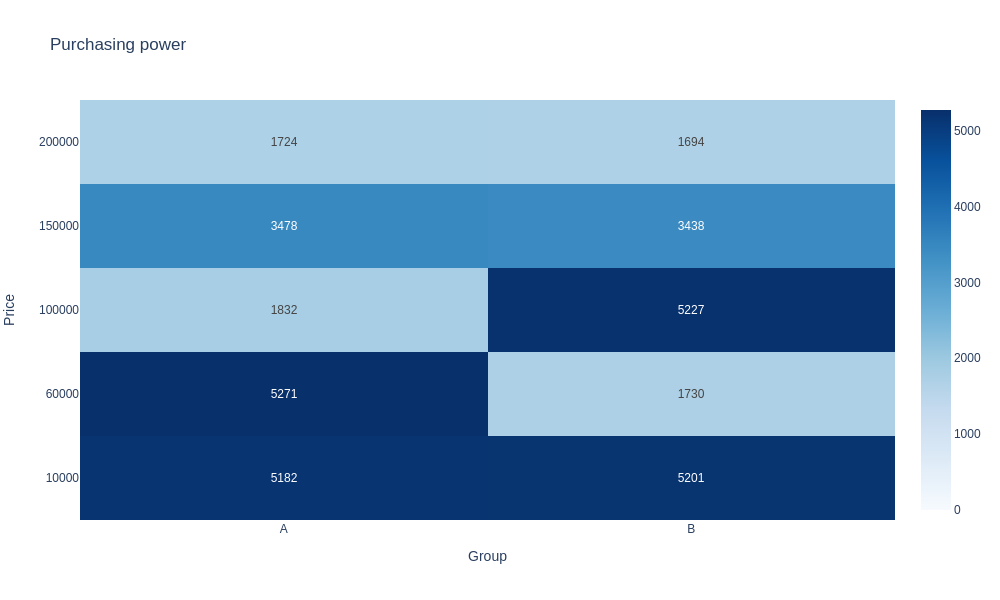

In [97]:
power_fig = go.Figure(
    data=[
        go.Heatmap(z=power_pt, x=power_pt.columns, y=power_pt.index, 
                   zmin=0, zmax=power_pt.max().max(),
                   text=power_pt, texttemplate="%{text}",
                   colorscale=px.colors.sequential.Blues)
    ]
)
power_fig.update_layout(
          autosize=False,
          width=1000,
          height=600,
          title_text="Purchasing power")
power_fig.update_yaxes(title_text='Price')
power_fig.update_xaxes(title_text='Group')
power_fig.write_html('images/power.html')
power_fig.write_image('images/power.png')
power_fig.show('png')
# power_fig.show()

> Significant difference in number of purchases were observed in price categories `60000` (sample `A` purchases is greater than that of sample `B`) and `100000` (sample `A` purchases is lower than that of `B`). Since $100000 > 60000$ then probably sample `B` daily average bill is greater than that of `A`.

## Cumulative metrics

### Daily features analysis

In [98]:
# Daily features generation
grouped_data_filtered = data_filtered.groupby(by=['date', 'group']).agg({
    'user_id': 'count', 
    'purchase': 'sum', 
    'price': 'sum'}).reset_index().rename(columns={'user_id': 'user_count'})
grouped_data_filtered.tail()

,date,group,user_count,purchase,price
41,2021-01-22,B,6659,787,68660000
42,2021-01-23,A,6698,843,70950000
43,2021-01-23,B,6633,805,68930000
44,2021-01-24,A,3766,444,33250000
45,2021-01-24,B,3677,442,38650000


In [99]:
grouped_data_filtered['conversion'] = grouped_data_filtered['purchase'] / grouped_data_filtered['user_count']
grouped_data_filtered['average_bill'] = grouped_data_filtered['price'] / grouped_data_filtered['purchase']

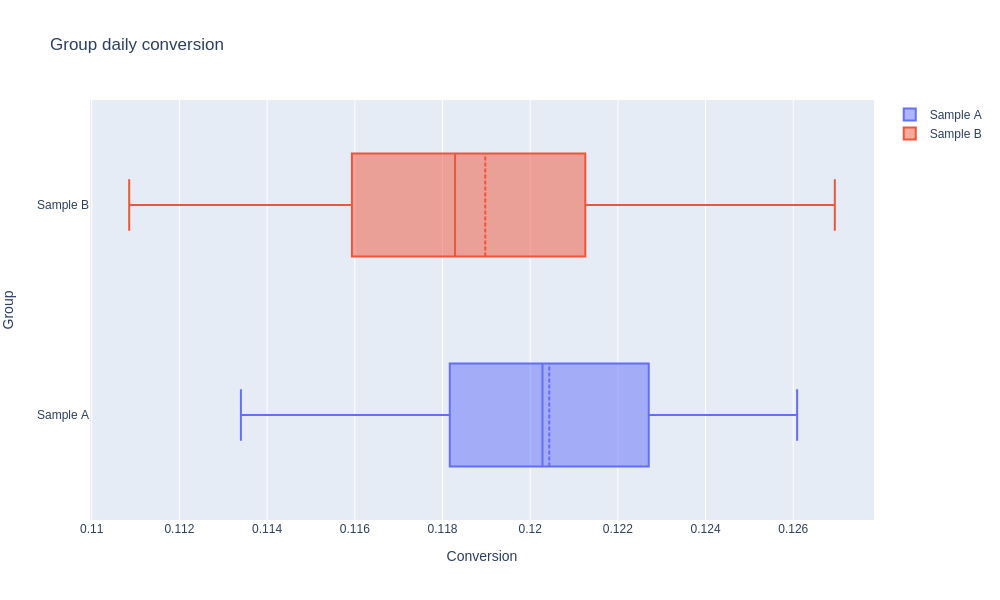

In [100]:
# Daily conversion
daily_a = grouped_data_filtered[grouped_data_filtered['group'] == 'A'].copy()
daily_b = grouped_data_filtered[grouped_data_filtered['group'] == 'B'].copy()

conversion_fig = go.Figure()
conversion_fig.add_trace(
    go.Box(x=daily_a['conversion'], name='Sample A', boxmean=True)
)
conversion_fig.add_trace(
    go.Box(x=daily_b['conversion'], name='Sample B', boxmean=True)
)
conversion_fig.update_layout(
          autosize=False,
          width=1000,
          height=600,
          title_text="Group daily conversion")
conversion_fig.update_xaxes(title_text='Conversion')
conversion_fig.update_yaxes(title_text='Group')
conversion_fig.write_html('images/conversion.html')
conversion_fig.write_image('images/conversion.png')
conversion_fig.show('png')
# conversion_fig.show()

In [101]:
conversion_pt = grouped_data_filtered.groupby('group')['conversion'].agg(['mean', 'median'])
display(conversion_pt)

,mean,median
group,,
A,0.120433,0.120281
B,0.118977,0.118286


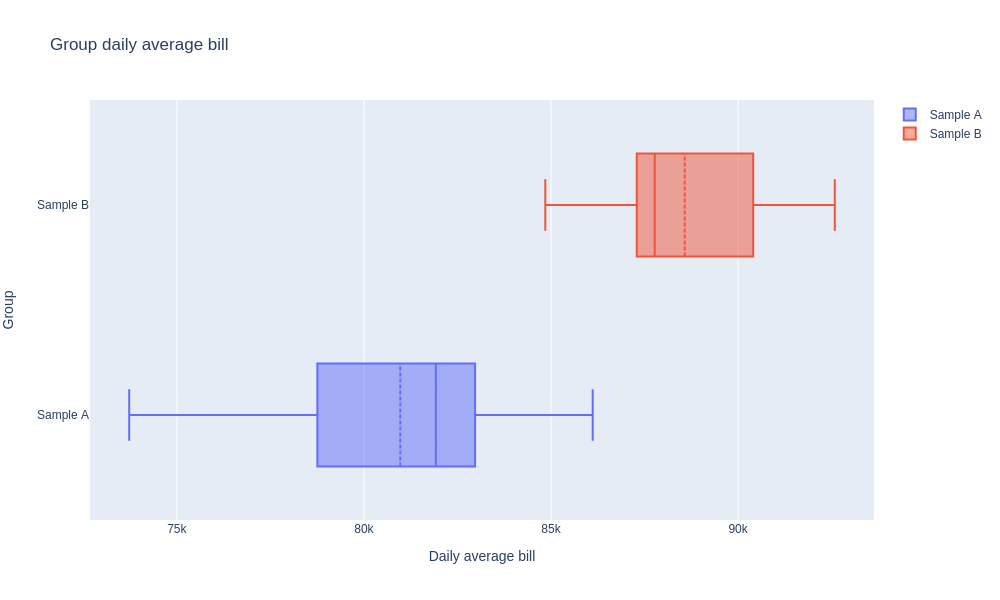

In [102]:
# Daily average bill
bill_fig = go.Figure()
bill_fig.add_trace(
    go.Box(x=daily_a['average_bill'], name='Sample A', boxmean=True)
)
bill_fig.add_trace(
    go.Box(x=daily_b['average_bill'], name='Sample B', boxmean=True)
)
bill_fig.update_layout(
          autosize=False,
          width=1000,
          height=600,
          title_text="Group daily average bill")
bill_fig.update_xaxes(title_text='Daily average bill')
bill_fig.update_yaxes(title_text='Group')
bill_fig.write_html('images/bill.html')
bill_fig.write_image('images/bill.png')
bill_fig.show('png')
# bill_fig.show()

In [103]:
bill_pt = grouped_data_filtered.groupby('group')['average_bill'].agg(['mean', 'median'])
display(bill_pt)

,mean,median
group,,
A,80969.285099,81922.005571
B,88575.715514,87770.935961


> There is a difference in daily conversions that seems insignificant. Daily average bill of sample `B` is greater than that of sample `A`. The significance of this difference should be proven with statistical tests.

### Cumulative daily features

In [104]:
grouped_data_filtered.tail()

,date,group,user_count,purchase,price,conversion,average_bill
41,2021-01-22,B,6659,787,68660000,0.118186,87242.693774
42,2021-01-23,A,6698,843,70950000,0.125858,84163.701068
43,2021-01-23,B,6633,805,68930000,0.121363,85627.329193
44,2021-01-24,A,3766,444,33250000,0.117897,74887.387387
45,2021-01-24,B,3677,442,38650000,0.120207,87443.438914


In [105]:
grouped_data_filtered['visit_cum'] = grouped_data_filtered['user_count'].cumsum()
grouped_data_filtered['purchase_cum'] = grouped_data_filtered['purchase'].cumsum()
grouped_data_filtered['price_cum'] = grouped_data_filtered['price'].cumsum()
grouped_data_filtered['conversion_cum'] = grouped_data_filtered['purchase_cum'] / grouped_data_filtered['visit_cum']
grouped_data_filtered['average_bill_cum'] = grouped_data_filtered['price_cum'] / grouped_data_filtered['purchase_cum']
grouped_data_filtered.head()

,date,group,user_count,purchase,price,conversion,average_bill,visit_cum,purchase_cum,price_cum,conversion_cum,average_bill_cum
0,2021-01-02,A,2854,359,29410000,0.125788,81922.005571,2854,359,29410000,0.125788,81922.005571
1,2021-01-02,B,2861,345,29660000,0.120587,85971.014493,5715,704,59070000,0.123185,83906.250000
2,2021-01-03,A,6596,748,62000000,0.113402,82887.700535,12311,1452,121070000,0.117943,83381.542700
3,2021-01-03,B,6619,754,65960000,0.113914,87480.106101,18930,2206,187030000,0.116535,84782.411605
4,2021-01-04,A,6566,799,64250000,0.121687,80413.016270,25496,3005,251280000,0.117862,83620.632280


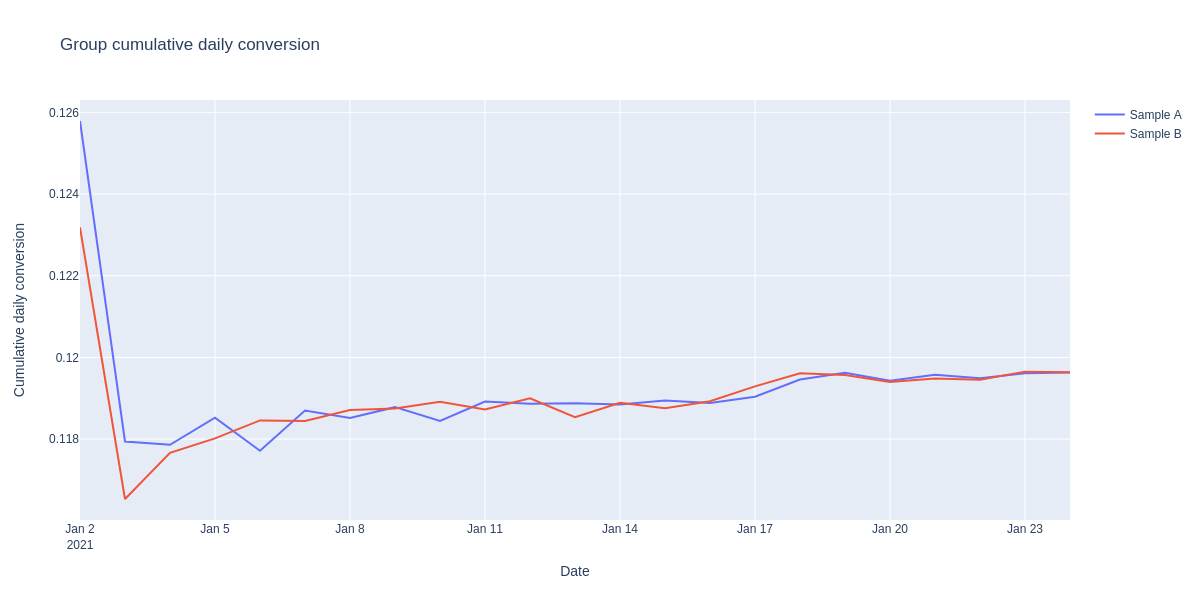

In [106]:
sample_a = grouped_data_filtered[grouped_data_filtered['group'] == 'A'].copy()
sample_b = grouped_data_filtered[grouped_data_filtered['group'] == 'B'].copy()

cum_conversion_fig = go.Figure()
cum_conversion_fig.add_trace(
    go.Scatter(x=sample_a['date'], 
               y=sample_a['conversion_cum'], 
               name='Sample A')
)
cum_conversion_fig.add_trace(
    go.Scatter(x=sample_b['date'], 
               y=sample_b['conversion_cum'], 
               name='Sample B')
)
cum_conversion_fig.update_layout(
          autosize=False,
          width=1200,
          height=600,
          title_text="Group cumulative daily conversion")
cum_conversion_fig.update_xaxes(title_text='Date')
cum_conversion_fig.update_yaxes(title_text='Cumulative daily conversion')
cum_conversion_fig.write_html('images/cum_conversion.html')
cum_conversion_fig.write_image('images/cum_conversion.png')
cum_conversion_fig.show('png')
# cum_conversion_fig.show()

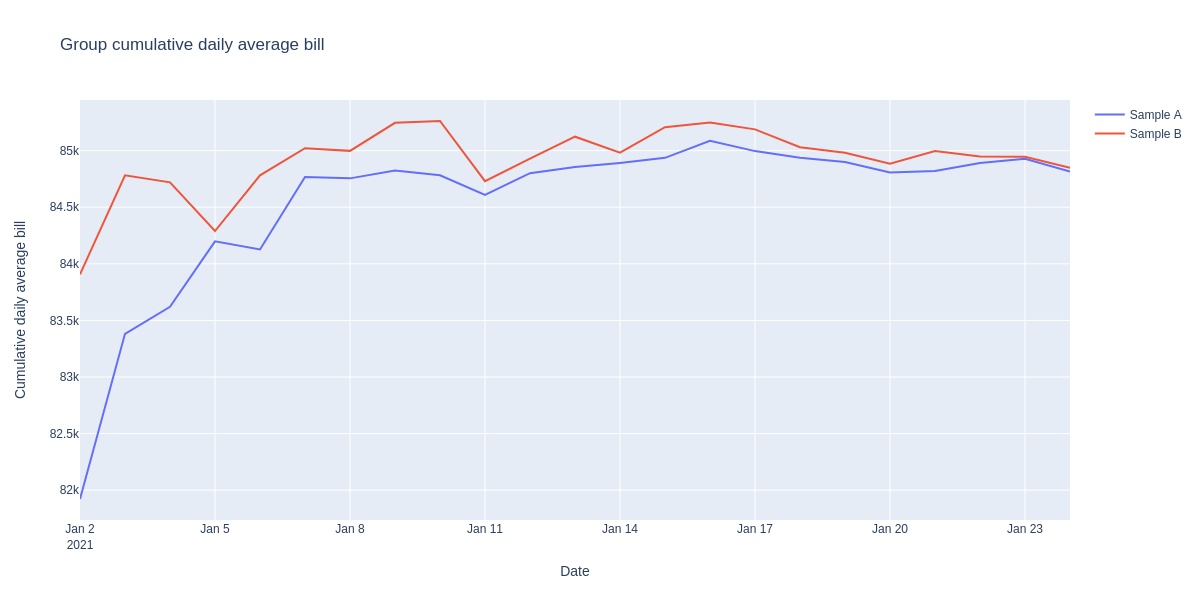

In [107]:
cum_bill_fig = go.Figure()
cum_bill_fig.add_trace(
    go.Scatter(x=sample_a['date'], 
               y=sample_a['average_bill_cum'], 
               name='Sample A')
)
cum_bill_fig.add_trace(
    go.Scatter(x=sample_b['date'], 
               y=sample_b['average_bill_cum'], 
               name='Sample B')
)
cum_bill_fig.update_layout(
          autosize=False,
          width=1200,
          height=600,
          title_text="Group cumulative daily average bill")
cum_bill_fig.update_xaxes(title_text='Date')
cum_bill_fig.update_yaxes(title_text='Cumulative daily average bill')
cum_bill_fig.write_html('images/cum_bill.html')
cum_bill_fig.write_image('images/cum_bill.png')
cum_bill_fig.show('png')
# cum_bill_fig.show()

> Cumulative daily conversion stabilized at level $11.96 \%$. Cumulative daily average bill stops at $84.9 k$ and then slightly declines. These facts indicate that A/B test can be treated as finished.

## Statistical tests

In [108]:
from statsmodels.stats.proportion import proportions_chisquare
from scipy.stats import shapiro
from scipy.stats import ttest_ind

In [109]:
alpha = 0.05 # significance level
gamma = 1 - alpha # confidence level

### Conversion tests

In [110]:
converted_pt= data_filtered.groupby('group')['purchase'].agg(['sum', 'count'])
display(converted_pt)

,sum,count
group,,
A,17487,145307
B,17290,145381


*Conversion is a Bernoulli-distributed random variable. Since A/B test duration is shorter than 30 days, $\chi^2$-test for proportions should be implemented.*

In [111]:
# Chi-square test for proportions
_, p_value, c = proportions_chisquare(
    count=converted_pt['sum'], 
    nobs=converted_pt['count']
)

print('p-value: ', round(p_value, 3))

if (p_value <= alpha):
    print("Decline null hypothesis. Conversions in samples are different.")
else:
    print("No reason to decline null hypothesis. Conversions in samples are equal.")

p-value:  0.239
No reason to decline null hypothesis. Conversions in samples are equal.


### Average bill tests

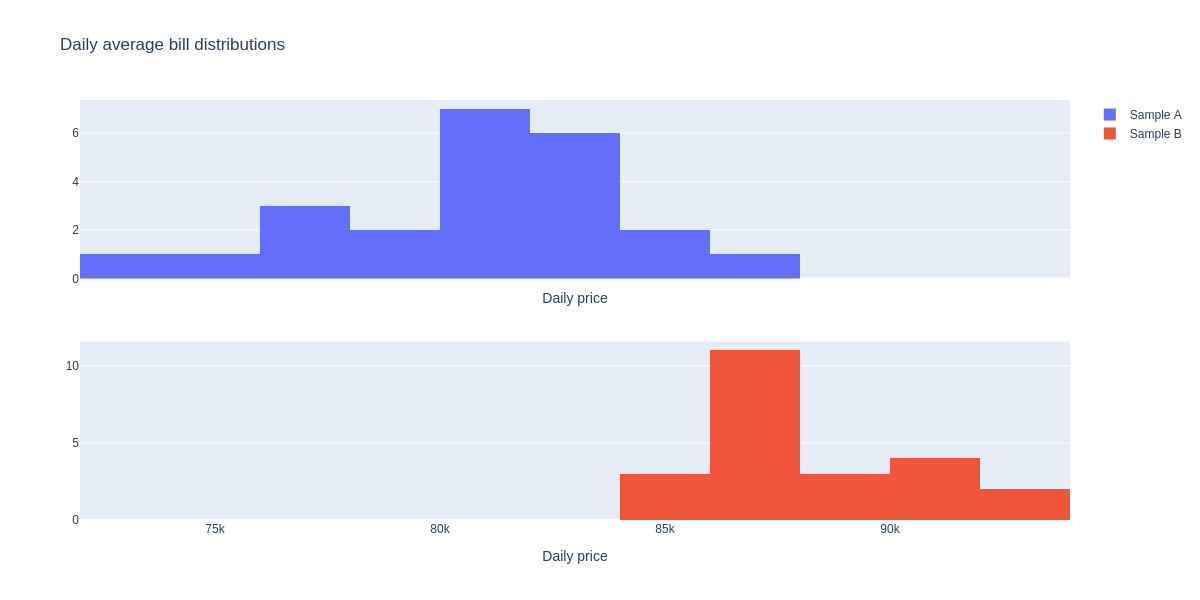

In [112]:
bill_hist = make_subplots(rows=2, cols=1, shared_xaxes=True)
bill_hist.add_trace(go.Histogram(x=sample_a['average_bill'], name='Sample A'), 
                    row=1, col=1)
bill_hist.add_trace(go.Histogram(x=sample_b['average_bill'], name='Sample B'), 
                    row=2, col=1)
bill_hist.update_layout(autosize=False,
                        width=1200,
                        height=600,
                        title_text="Daily average bill distributions")
bill_hist.update_xaxes(title_text='Daily price')
bill_hist.write_html('images/hist_bill.html')
bill_hist.write_image('images/hist_bill.png')
bill_hist.show('png')
# bill_hist.show()

In [113]:
# Normality check (Shapiro's test)
shapiro_result_a = shapiro(sample_a['average_bill'])
shapiro_result_b = shapiro(sample_b['average_bill'])
print('Sample А p-value: ', round(shapiro_result_a.pvalue, 2))
print('Sample B p-value: ', round(shapiro_result_b.pvalue, 2))

if shapiro_result_a.pvalue <= alpha:
    print("Decline null hypothesis. Sample A average bill distribution isn't normal.")
else:
    print("Accept null hypothesis. Sample A average bill distribution is normal.")

if shapiro_result_b.pvalue <= alpha:
    print("Decline null hypothesis. Sample B average bill distribution isn't normal.")
else:
    print("Accept null hypothesis. Sample B average bill distribution is normal.")

Sample А p-value:  0.25
Sample B p-value:  0.09
Accept null hypothesis. Sample A average bill distribution is normal.
Accept null hypothesis. Sample B average bill distribution is normal.


*With confidence level $\gamma = 95\%$ both samples' average bill distribution are normal. Implement two-sampled t-criterion.*

In [114]:
# Two-sided two-sampled t-criterion
results = ttest_ind(
    a=sample_a['average_bill'],
    b=sample_b['average_bill'],
    alternative='two-sided'
)
print('p-value:', round(results.pvalue, 2))

if results.pvalue <= alpha:
    print("Decline null hypothesis. Average bill in samples are different.")
else:
    print("Accept null hypothesis. Average bill in samples are equal.")

p-value: 0.0
Decline null hypothesis. Average bill in samples are different.


In [115]:
# One-sided two-sampled t-criterium
results = ttest_ind(
    a=sample_a['average_bill'],
    b=sample_b['average_bill'],
    alternative='less'
)
print('p-value:', round(results.pvalue, 2))

if results.pvalue <= alpha:
    print("Decline null hypothesis. Sample B average bill is greater than that of sample A.")
else:
    print("Accept null hypothesis. Sample B average bill isn't greater than that of sample A.")

p-value: 0.0
Decline null hypothesis. Sample B average bill is greater than that of sample A.


> With confidence level $\gamma = 95\%$ daily conversion in both samples are the same. Daily average bill of sample `B` is greater than that of sample `A`.

### Confidence intervals

In [116]:
from scipy.stats import norm, t

In [117]:
gamma = 0.95 # confidence level

#### Conversion

In [118]:
def proportion_conf_interval(x_p, n, gamma=0.95):
    """Calculate lower and upper bounds of confidence inverval (CI) for proportion.

    Args:
        x_p (float): sample mean.
        n (int): sample standard deviation.
        gamma (float, optional): confidence level. Defaults to 0.95.

    Returns:
        tuple(float, float): (CI lower bound, CI upper bound).
    """
    
    z_crit = - norm.ppf((1 - gamma)/2)
    eps = z_crit * (x_p * (1 - x_p) / n) ** 0.5
    lower_bound = x_p - eps
    upper_bound = x_p + eps

    return lower_bound, upper_bound

In [119]:
# Implementing normal distribution for proportions
lower_conv_a, upper_conv_a = proportion_conf_interval(
    x_p=sample_a['conversion'].mean(), 
    n=sample_a.shape[0]
)

lower_conv_b, upper_conv_b = proportion_conf_interval(
    x_p=sample_b['conversion'].mean(), 
    n=sample_b.shape[0]
)

print(f"Sample A CI for conversion: {(round(lower_conv_a * 100, 2), round(upper_conv_a * 100, 2))}")
print(f"Sample B CI for conversion: {(round(lower_conv_b * 100, 2), round(upper_conv_b * 100, 2))}")

Sample A CI for conversion: (-1.26, 25.34)
Sample B CI for conversion: (-1.33, 25.13)


#### Conversion difference

In [120]:
def diff_proportion_conf_interval(x_p, n, gamma=0.95):
    """Calculate CI lower and upper bounds for difference of proportions.

    Args:
        x_p (list(float, float)): list of sample mean.
        n (list(int, int)): list of number of observations in samples.
        gamma (float, optional): confidence level. Defaults to 0.95.

    Returns:
        tuple(float, float): (CI lower bound, CI upper bound).
    """
    
    diff = x_p[1] - x_p[0]
    z_crit = -norm.ppf((1 - gamma)/2)
    eps = z_crit * (x_p[0] * (1 - x_p[0])/n[0] + x_p[1] * (1 - x_p[1])/n[1]) ** 0.5
    lower_bound = diff - eps
    upper_bound = diff + eps

    return lower_bound, upper_bound

In [121]:
# Implementing normal distribution for difference of proportions
n_samples = [sample_a.shape[0], sample_b.shape[0]]
x_means = [sample_a['conversion'].mean(), sample_b['conversion'].mean()]

lower_diff, upper_diff = diff_proportion_conf_interval(x_p=x_means, n=n_samples)
print(f"CI for conversion difference: {(round(lower_diff, 2), round(upper_diff, 2))}")

CI for conversion difference: (-0.19, 0.19)


#### Daily average bill

In [122]:
# Implementing T-distribution
n_a = sample_a.shape[0]
n_b = sample_b.shape[0]
x_mean_a = sample_a['average_bill'].mean()
x_mean_b = sample_b['average_bill'].mean()
x_std_a = sample_a['average_bill'].std()
x_std_b = sample_b['average_bill'].std()

lower_bill_a, upper_bill_a = t.interval(gamma, df = n_a - 1, loc = x_mean_a, scale = x_std_a/(n_a ** 0.5))
lower_bill_b, upper_bill_b = t.interval(gamma, df = n_b - 1, loc = x_mean_b, scale = x_std_b/(n_b ** 0.5))

print(f"Sample A CI for daily average bill: {(round(lower_bill_a), round(upper_bill_a))}")
print(f"Sample B CI for daily average bill: {(round(lower_bill_b), round(upper_bill_b))}")

Sample A CI for daily average bill: (79630, 82308)
Sample B CI for daily average bill: (87626, 89526)


> Daily conversion `CI`s intersect each other:  daily conversions of both samples are equal. `CI` for conversion difference surrounds zero point: no statistical difference for daily conversions of both samples. Sample `B` daily average bill `CI` is to the right of sample `B`: sample `B` daily average bill is greater than that of sample `A`.

## Conclusion

> If the task is to maximize the profit then our choice is `B` variant (test variant) because of greater daily average bill. If the goal is better conversion the we should stay at `A` because daily conversions are almost the same and the profit of `B` won't cover the cost of its deployment.